# Stack Exchange question-thread EDA

**Objective.** The analysis describes one Stack Exchange community and one question period, identifies human-response patterns, and selects useful cases for qualitative analysis.

**Notebook structure.** Explanations define the data, settings, figures, and main observations, which makes the analysis independent of prior project knowledge.

**Scope.** Each table row represents one Stack Exchange question. Human-response indicators remain descriptive evidence. Difficulty labels require a separate documented assessment.


## Data origin and table structure

- Stack Exchange public data dumps use XML files.
- `Posts.xml` stores questions and answers. `PostTypeId = 1` identifies a question and `PostTypeId = 2` identifies an answer.
- `Comments.xml` stores comments separately. This project counts comments attached directly to questions.
- `Votes.xml` records acceptance events at calendar-day precision.
- `build_characteristics.py` combines these sources into one TSV table with one row per question.
- `config/characteristics.tsv` and `docs/reference/data-dictionary.xlsx` define the 49 fields, their sources, calculations, interpretations, and empty-value meanings.

The dump is a snapshot. Scores, views, answer counts, comments, and moderation events describe the state available at that snapshot.

In [1]:
# Libraries used directly for tables, statistics, and plots.
from itertools import combinations
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.ticker import MaxNLocator
from scipy import stats

## Editable settings

The next cell is the only routine editing point.

- **`DATA_FILE`** — path to a TSV produced by `build_characteristics.py`. Example: `Path("../data/processed/example-run/thread_characteristics.tsv")`.
- **`MIN_TAG_QUESTIONS`** — minimum question count for a tag-outcome comparison. Example: `10` permits smaller groups than `20`, with less stable percentages.
- **`TOP_TAGS_TO_SHOW`** — maximum tag count in Figure 8. Example: `10` produces a shorter figure than `15`.
- **`MIN_CORRELATION_OBSERVATIONS`** — minimum complete rows for one correlation. Example: `50` requires more evidence than `20`.
- **`MIN_ABSOLUTE_RHO`** — minimum displayed Spearman strength. Example: `0.50` retains stronger relationships than `0.30`.
- **`FDR_ALPHA`** — false-discovery-rate limit for correlations. `0.05` is the project setting.
- **`MAX_CASES_TO_SHOW`** — maximum rows in the final inspection table. Example: `5` produces a shorter table than `8`.

In [2]:
# Characteristic table analyzed by this run.
DATA_FILE = Path("../data/examples/characteristics_pilot.tsv")

# Evidence-selection settings for tags, correlations, and inspection cases.
MIN_TAG_QUESTIONS = 20
TOP_TAGS_TO_SHOW = 15
MIN_CORRELATION_OBSERVATIONS = 20
MIN_ABSOLUTE_RHO = 0.30
FDR_ALPHA = 0.05
MAX_CASES_TO_SHOW = 8


## 1. Table loading and verification

This section checks the settings, required fields, data types, and internal consistency before figures are produced. Execution stops with a specific error when the table does not satisfy the documented contract.

In [3]:
# Editable-setting validation.
if not isinstance(DATA_FILE, (str, Path)):
    raise TypeError("DATA_FILE must be a file path")
DATA_FILE = Path(DATA_FILE)

positive_integer_settings = {
    "MIN_TAG_QUESTIONS": MIN_TAG_QUESTIONS,
    "TOP_TAGS_TO_SHOW": TOP_TAGS_TO_SHOW,
    "MIN_CORRELATION_OBSERVATIONS": MIN_CORRELATION_OBSERVATIONS,
    "MAX_CASES_TO_SHOW": MAX_CASES_TO_SHOW,
}
for name, value in positive_integer_settings.items():
    if isinstance(value, bool) or not isinstance(value, int) or value < 1:
        raise ValueError(f"{name} must be a whole number greater than zero")

if MIN_CORRELATION_OBSERVATIONS < 3:
    raise ValueError("MIN_CORRELATION_OBSERVATIONS must be at least 3")
for name, value in {
    "MIN_ABSOLUTE_RHO": MIN_ABSOLUTE_RHO,
    "FDR_ALPHA": FDR_ALPHA,
}.items():
    if isinstance(value, bool) or not isinstance(value, (int, float)):
        raise TypeError(f"{name} must be a number")
if not 0 <= MIN_ABSOLUTE_RHO <= 1:
    raise ValueError("MIN_ABSOLUTE_RHO must be between 0 and 1")
if not 0 < FDR_ALPHA <= 1:
    raise ValueError("FDR_ALPHA must be greater than 0 and at most 1")

display(Markdown("**Settings check:** all editable settings are valid."))


**Settings check:** all editable settings are valid.

In [4]:
# File loading and required-column check.
if not DATA_FILE.is_file():
    raise FileNotFoundError(f"Characteristic table not found: {DATA_FILE.resolve()}")

data = pd.read_csv(DATA_FILE, sep="\t", low_memory=False)
source_column_count = len(data.columns)
if data.empty:
    raise ValueError("The characteristic table contains no question rows")

required_columns = {
    "site", "dump_snapshot_date", "question_id", "question_url",
    "question_creation_datetime", "question_title", "question_tags",
    "question_score", "question_view_count", "question_word_count",
    "code_character_count", "link_count", "image_count", "tag_count",
    "stackexchange_answer_count", "has_stackexchange_answer",
    "stackexchange_comment_count", "available_answer_count",
    "has_available_answer", "first_answer_creation_datetime",
    "time_to_first_answer_hours", "median_answer_response_hours",
    "accepted_answer_id", "accepted_answer_available",
    "time_to_eventually_accepted_answer_post_hours", "acceptance_date",
    "days_to_acceptance", "closed_datetime", "answer_score_spread",
    "available_question_comment_count", "comments_before_first_answer",
    "observation_days_at_dump",
}
missing_columns = sorted(required_columns - set(data.columns))
if missing_columns:
    raise ValueError("Missing required column(s): " + ", ".join(missing_columns))

In [5]:
# Source-date, numeric, and TRUE/FALSE conversion.
date_columns = [
    "dump_snapshot_date", "question_creation_datetime",
    "first_answer_creation_datetime", "acceptance_date", "closed_datetime",
]
for column in date_columns:
    data[column] = pd.to_datetime(data[column], errors="raise")

numeric_columns = [
    "question_score", "question_view_count", "question_word_count",
    "code_character_count", "link_count", "image_count", "tag_count",
    "stackexchange_answer_count", "stackexchange_comment_count",
    "available_answer_count", "time_to_first_answer_hours",
    "median_answer_response_hours", "time_to_eventually_accepted_answer_post_hours",
    "days_to_acceptance", "answer_score_spread",
    "available_question_comment_count", "comments_before_first_answer",
    "observation_days_at_dump",
]
for column in numeric_columns:
    data[column] = pd.to_numeric(data[column], errors="raise")

for column in ["has_stackexchange_answer", "has_available_answer", "accepted_answer_available"]:
    boolean_text = data[column].astype("string").str.upper()
    invalid = boolean_text.notna() & ~boolean_text.isin(["TRUE", "FALSE"])
    if invalid.any():
        raise ValueError(f"{column} contains a value outside TRUE, FALSE, and empty")
    if column in {"has_available_answer", "accepted_answer_available"} and boolean_text.isna().any():
        raise ValueError(f"{column} contains an empty value")
    data[column] = boolean_text.map({"TRUE": True, "FALSE": False}).astype("boolean")

In [6]:
# Cross-field and dataset-level consistency checks.
expected_stackexchange_flag = data["stackexchange_answer_count"].gt(0).astype("boolean")
expected_stackexchange_flag[data["stackexchange_answer_count"].isna()] = pd.NA
if not data["has_stackexchange_answer"].equals(expected_stackexchange_flag):
    raise ValueError("has_stackexchange_answer disagrees with stackexchange_answer_count")
expected_available_flag = data["available_answer_count"].gt(0).astype("boolean")
if not data["has_available_answer"].equals(expected_available_flag):
    raise ValueError("has_available_answer disagrees with available_answer_count")
if data["question_id"].isna().any() or data["question_id"].duplicated().any():
    raise ValueError("Question identifiers must be present and unique")

nonnegative_columns = [
    "question_view_count", "question_word_count", "code_character_count",
    "link_count", "image_count", "tag_count", "available_answer_count",
    "time_to_first_answer_hours", "median_answer_response_hours",
    "time_to_eventually_accepted_answer_post_hours", "days_to_acceptance",
    "answer_score_spread", "available_question_comment_count",
    "comments_before_first_answer", "observation_days_at_dump",
]
for column in nonnegative_columns:
    if (data[column].dropna() < 0).any():
        raise ValueError(f"{column} contains a negative value")

sites = data["site"].dropna().unique()
if len(sites) != 1:
    raise ValueError(f"Expected one site, found {len(sites)}")
snapshot_dates = data["dump_snapshot_date"].dropna().dt.normalize().unique()
if len(snapshot_dates) != 1:
    raise ValueError(f"Expected one dump snapshot date, found {len(snapshot_dates)}")
for column in ["question_creation_datetime", "first_answer_creation_datetime", "acceptance_date", "closed_datetime"]:
    if (data[column].dropna() > data["dump_snapshot_date"].max()).any():
        raise ValueError(f"{column} contains a date after the dump snapshot")

data["has_accepted_answer"] = data["accepted_answer_id"].notna()
data["is_closed"] = data["closed_datetime"].notna()

In [7]:
# Compact description of the verified table.
summary = pd.DataFrame({
    "Item": ["Site", "Questions", "Source columns", "Question period", "Dump snapshot"],
    "Value": [
        sites[0],
        f"{len(data):,}",
        f"{source_column_count:,}",
        f"{data['question_creation_datetime'].min():%Y-%m-%d} to {data['question_creation_datetime'].max():%Y-%m-%d}",
        f"{data['dump_snapshot_date'].max():%Y-%m-%d}",
    ],
})
display(summary)

# Each later figure records whether sufficient evidence was available.
figure_status = []


,Item,Value
0,Site,softwareengineering.stackexchange.com
1,Questions,20
2,Source columns,49
3,Question period,2024-01-01 to 2024-01-08
4,Dump snapshot,2026-04-20


## 2. Figure 1 — Table quality and overall outcomes

Figure 1a counts questions reaching observable outcomes by the dump snapshot. These overlapping groups describe community activity.

Figure 1b reports the largest empty-value shares among analysis measurements. Event-based fields are empty when their event is absent. The consistency table compares related source and reconstructed values.

In [8]:
# Figure 1a: overlapping question outcomes.
status_counts = pd.Series({
    "All selected questions": len(data),
    "Questions with an answer": int(data["has_available_answer"].sum()),
    "Questions with an accepted answer": int(data["has_accepted_answer"].sum()),
    "Closed questions": int(data["is_closed"].sum()),
})

# Figure 1b: fields with the largest empty-value shares.
availability_columns = [
    "time_to_first_answer_hours", "median_answer_response_hours",
    "time_to_eventually_accepted_answer_post_hours", "days_to_acceptance",
    "answer_score_spread", "question_view_count", "question_word_count",
    "code_character_count", "available_question_comment_count",
]
availability_labels = {
    "time_to_first_answer_hours": "Hours to first answer",
    "median_answer_response_hours": "Median answer delay",
    "time_to_eventually_accepted_answer_post_hours": "Hours to accepted-answer post",
    "days_to_acceptance": "Days to acceptance action",
    "answer_score_spread": "Answer-score spread",
    "question_view_count": "Question views",
    "question_word_count": "Question prose words",
    "code_character_count": "Code characters",
    "available_question_comment_count": "Question comments",
}
missing_percentages = (data[availability_columns].isna().mean() * 100).sort_values(ascending=False).head(7)
missing_percentages.index = [availability_labels[column] for column in missing_percentages.index]

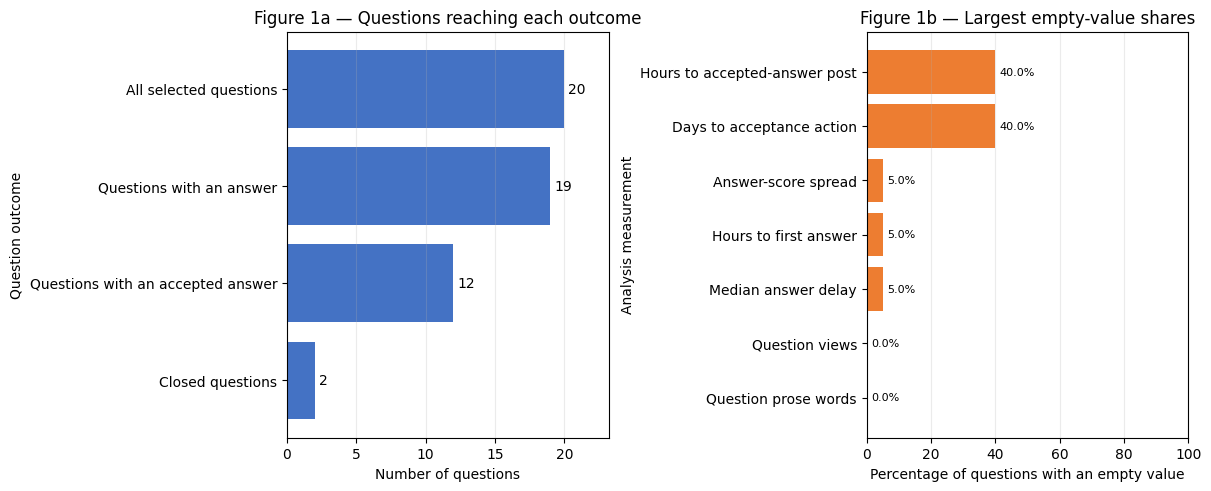

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), layout="constrained")
bars = axes[0].barh(status_counts.index, status_counts.values, color="#4472C4")
axes[0].invert_yaxis()
axes[0].set_title("Figure 1a — Questions reaching each outcome")
axes[0].set_xlabel("Number of questions")
axes[0].set_ylabel("Question outcome")
axes[0].grid(axis="x", alpha=0.25)
axes[0].bar_label(bars, labels=[f"{value:,}" for value in status_counts.values], padding=3)
axes[0].set_xlim(0, max(1, status_counts.max() * 1.16))

missing_to_plot = missing_percentages.sort_values()
bars = axes[1].barh(missing_to_plot.index, missing_to_plot.values, color="#ED7D31")
axes[1].set_title("Figure 1b — Largest empty-value shares")
axes[1].set_xlabel("Percentage of questions with an empty value")
axes[1].set_ylabel("Analysis measurement")
axes[1].set_xlim(0, 100)
axes[1].grid(axis="x", alpha=0.25)
axes[1].bar_label(bars, labels=[f"{value:.1f}%" for value in missing_to_plot.values], padding=3, fontsize=8)
plt.show()

In [10]:
answer_count_difference = (
    data["stackexchange_answer_count"].notna()
    & data["stackexchange_answer_count"].ne(data["available_answer_count"])
)
comment_count_difference = (
    data["stackexchange_comment_count"].notna()
    & data["stackexchange_comment_count"].ne(data["available_question_comment_count"])
)
accepted_row_missing = data["has_accepted_answer"] & ~data["accepted_answer_available"].fillna(False)
acceptance_date_missing = data["has_accepted_answer"] & data["acceptance_date"].isna()
consistency = pd.DataFrame({
    "Consistency check": [
        "Stack Exchange answer count differs from available answer rows",
        "Stack Exchange comment count differs from available question-comment rows",
        "Accepted-answer identifier has no available answer row",
        "Accepted-answer identifier has no recorded acceptance date",
    ],
    "Questions": [
        int(answer_count_difference.sum()), int(comment_count_difference.sum()),
        int(accepted_row_missing.sum()), int(acceptance_date_missing.sum()),
    ],
})
display(consistency)

total = len(data)
display(Markdown(
    "**Figure 1 interpretation**  \n"
    f"- **Answered:** {status_counts['Questions with an answer']:,} questions ({status_counts['Questions with an answer'] / total:.1%}).  \n"
    f"- **Accepted:** {status_counts['Questions with an accepted answer']:,} questions ({status_counts['Questions with an accepted answer'] / total:.1%}).  \n"
    f"- **Closed:** {status_counts['Closed questions']:,} questions ({status_counts['Closed questions'] / total:.1%}).  \n"
    f"- The largest empty-value share is **{missing_percentages.iloc[0]:.1f}%** for **{missing_percentages.index[0]}**.  \n"
    "- Count differences identify source-state cases for review. They remain visible in the table instead of being silently replaced."
))
figure_status.append({"Figure": "1", "Status": "Produced", "Evidence": "Outcome, availability, and consistency checks"})

,Consistency check,Questions
0,Stack Exchange answer count differs from avail...,0
1,Stack Exchange comment count differs from avai...,0
2,Accepted-answer identifier has no available an...,0
3,Accepted-answer identifier has no recorded acc...,0


**Figure 1 interpretation**  
- **Answered:** 19 questions (95.0%).  
- **Accepted:** 12 questions (60.0%).  
- **Closed:** 2 questions (10.0%).  
- The largest empty-value share is **40.0%** for **Hours to accepted-answer post**.  
- Count differences identify source-state cases for review. They remain visible in the table instead of being silently replaced.

## 3. Figure 2 — Cumulative monthly outcome evolution

Every month includes questions and events from that month and all preceding months. The stacked areas divide all questions posted so far into questions already answered and questions still waiting for an answer. The lines add recorded acceptance and closure events.

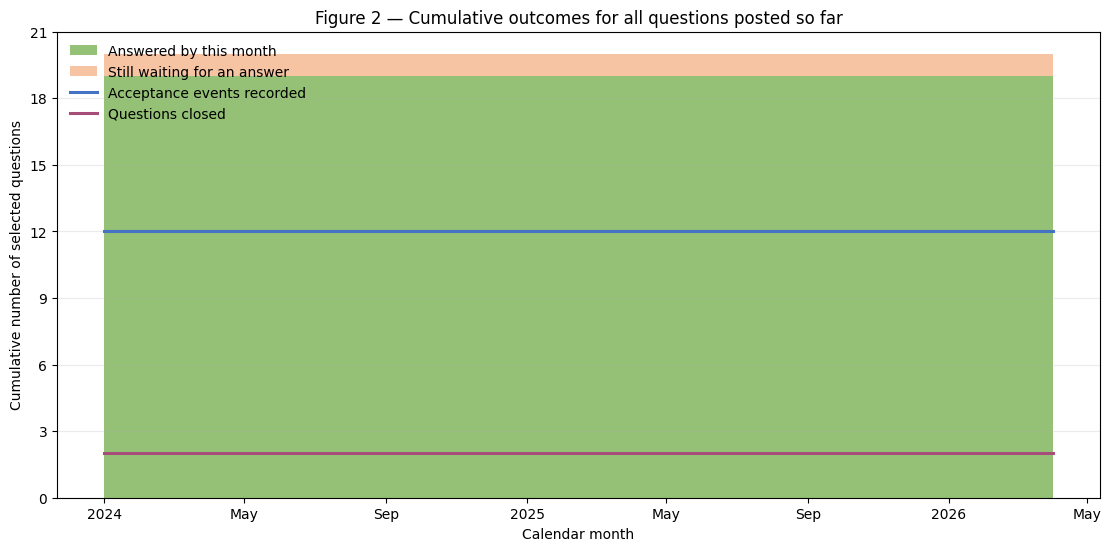

**Figure 2 interpretation**  
- The timeline covers **January 2024** through **April 2026**.  
- At the snapshot, **19** questions had an available answer and **1** were still waiting.  
- **12** acceptance events and **2** closures were recorded.  
- A flat segment means that no additional selected question reached that event during the segment.

In [11]:
first_month = data["question_creation_datetime"].min().to_period("M").to_timestamp()
last_month = data["dump_snapshot_date"].max().to_period("M").to_timestamp()
months = pd.date_range(first_month, last_month, freq="MS")

def cumulative_monthly_count(dates):
    """Returns cumulative event counts on the shared monthly timeline."""
    event_months = dates.dropna().dt.to_period("M").dt.to_timestamp()
    return event_months.value_counts().reindex(months, fill_value=0).cumsum()

posted = cumulative_monthly_count(data["question_creation_datetime"])
answered = cumulative_monthly_count(data["first_answer_creation_datetime"])
acceptance_events = cumulative_monthly_count(data["acceptance_date"])
closed = cumulative_monthly_count(data["closed_datetime"])
still_waiting = posted - answered

fig, ax = plt.subplots(figsize=(11, 5.4), layout="constrained")
ax.stackplot(
    months, answered, still_waiting,
    labels=["Answered by this month", "Still waiting for an answer"],
    colors=["#70AD47", "#F4B183"], alpha=0.75,
)
ax.plot(months, acceptance_events, color="#4472C4", linewidth=2.2, label="Acceptance events recorded")
ax.plot(months, closed, color="#A64D79", linewidth=2.2, label="Questions closed")
ax.set_title("Figure 2 — Cumulative outcomes for all questions posted so far")
ax.set_xlabel("Calendar month")
ax.set_ylabel("Cumulative number of selected questions")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
locator = mdates.AutoDateLocator(minticks=4, maxticks=9)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False, loc="upper left")
plt.show()

display(Markdown(
    "**Figure 2 interpretation**  \n"
    f"- The timeline covers **{first_month:%B %Y}** through **{last_month:%B %Y}**.  \n"
    f"- At the snapshot, **{int(answered.iloc[-1]):,}** questions had an available answer and **{int(still_waiting.iloc[-1]):,}** were still waiting.  \n"
    f"- **{int(acceptance_events.iloc[-1]):,}** acceptance events and **{int(closed.iloc[-1]):,}** closures were recorded.  \n"
    "- A flat segment means that no additional selected question reached that event during the segment."
))
figure_status.append({"Figure": "2", "Status": "Produced", "Evidence": f"{len(months)} cumulative calendar months"})

## 4. Figure 3 — Outcomes by question-creation cohort

A cohort contains questions posted in the same calendar month. Figure 3 reports the eventual outcome observed by the dump snapshot for each posting cohort. These percentages describe separate monthly groups; they are distinct from the cumulative totals in Figure 2.

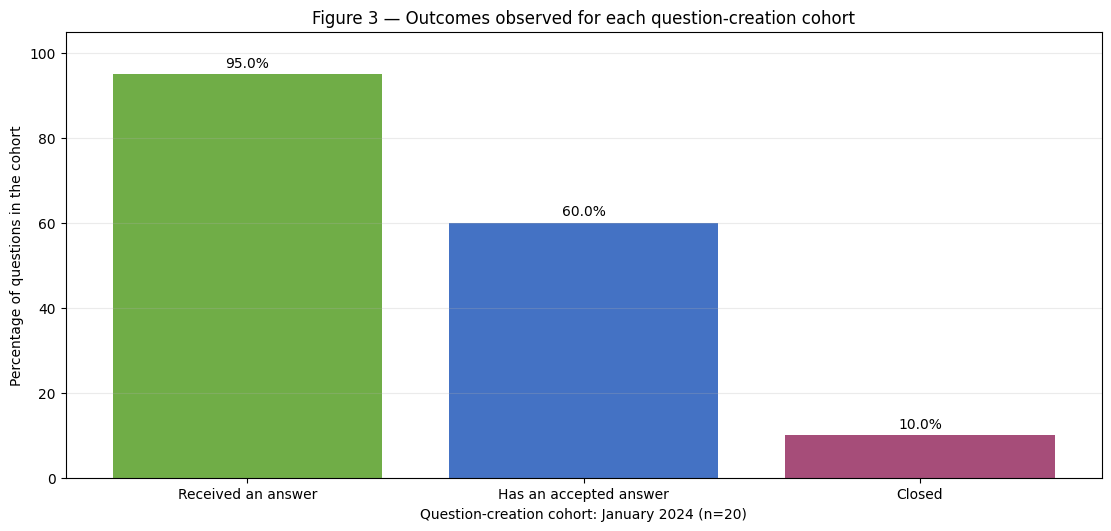

In [12]:
cohort = data.assign(
    creation_month=data["question_creation_datetime"].dt.to_period("M")
).groupby("creation_month").agg(
    questions=("question_id", "size"),
    answered_percentage=("has_available_answer", "mean"),
    accepted_percentage=("has_accepted_answer", "mean"),
    closed_percentage=("is_closed", "mean"),
)
cohort[["answered_percentage", "accepted_percentage", "closed_percentage"]] *= 100
cohort_dates = cohort.index.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 5.2), layout="constrained")
labels = {
    "answered_percentage": "Received an answer",
    "accepted_percentage": "Has an accepted answer",
    "closed_percentage": "Closed",
}
colors = ["#70AD47", "#4472C4", "#A64D79"]
if len(cohort) == 1:
    values = cohort.iloc[0][list(labels)]
    bars = ax.bar(labels.values(), values, color=colors)
    ax.bar_label(bars, labels=[f"{value:.1f}%" for value in values], padding=3)
    ax.set_xlabel(f"Question-creation cohort: {cohort_dates[0]:%B %Y} (n={int(cohort.iloc[0]['questions'])})")
else:
    for (column, label), color in zip(labels.items(), colors):
        ax.plot(cohort_dates, cohort[column], marker="o", linewidth=2, label=label, color=color)
    locator = mdates.AutoDateLocator(minticks=4, maxticks=10)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    ax.set_xlabel("Question-creation month")
    ax.legend(frameon=False, loc="best")
ax.set_title("Figure 3 — Outcomes observed for each question-creation cohort")
ax.set_ylabel("Percentage of questions in the cohort")
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.25)
plt.show()

In [13]:
# Cohort sizes and percentages underlying Figure 3.
cohort_table = cohort.reset_index()
cohort_table["creation_month"] = cohort_table["creation_month"].astype(str)
cohort_table = cohort_table.rename(columns={
    "creation_month": "Question-creation month",
    "questions": "Questions",
    "answered_percentage": "Answered (%)",
    "accepted_percentage": "Accepted (%)",
    "closed_percentage": "Closed (%)",
})
display(cohort_table.round(1))

largest_cohort = cohort["questions"].idxmax()
display(Markdown(
    "**Figure 3 interpretation**  \n"
    f"- The table contains **{len(cohort):,}** monthly posting cohort(s).  \n"
    f"- The largest cohort is **{largest_cohort.strftime('%B %Y')}** with **{int(cohort.loc[largest_cohort, 'questions']):,}** questions.  \n"
    f"- Cohort answered shares range from **{cohort['answered_percentage'].min():.1f}%** to **{cohort['answered_percentage'].max():.1f}%**.  \n"
    "- Later cohorts have shorter observation periods and therefore require cautious comparison with earlier cohorts."
))
figure_status.append({"Figure": "3", "Status": "Produced", "Evidence": f"{len(cohort)} creation-month cohorts"})

,Question-creation month,Questions,Answered (%),Accepted (%),Closed (%)
0,2024-01,20,95.0,60.0,10.0


**Figure 3 interpretation**  
- The table contains **1** monthly posting cohort(s).  
- The largest cohort is **January 2024** with **20** questions.  
- Cohort answered shares range from **95.0%** to **95.0%**.  
- Later cohorts have shorter observation periods and therefore require cautious comparison with earlier cohorts.

## 5. Figures 4 and 5 — Numeric distributions

The histograms use ordinary linear axes and equal-width bins. Axis labels show measured values and units. Compact integer ranges use one bar for each actual whole-number result.

The displayed range contains the central 95% of most measurements and the central 80% of response and acceptance delays. Values beyond the displayed range remain counted in the interpretation with their observed minimum and maximum. This keeps the common range readable while accounting for every available value.

In [14]:
def draw_distribution(ax, series, title, x_label, whole_numbers=False, lower_quantile=0, upper_quantile=0.95):
    """Draws one readable linear distribution and returns its summary."""
    values = series.dropna().astype(float)
    if values.empty:
        ax.text(0.5, 0.5, "No available values", ha="center", va="center")
        ax.set_axis_off()
        return None
    lower = float(values.quantile(lower_quantile)) if lower_quantile else float(values.min())
    upper = float(values.quantile(upper_quantile))
    if values.min() >= 0:
        lower = 0.0
    if whole_numbers:
        lower, upper = float(np.floor(lower)), float(np.ceil(upper))
    if upper <= lower:
        upper = max(float(values.max()), lower + 1)

    shown = values[(values >= lower) & (values <= upper)]
    if whole_numbers and upper - lower <= 20:
        points = np.arange(int(lower), int(upper) + 1)
        counts = shown.round().astype(int).value_counts().reindex(points, fill_value=0)
        ax.bar(points, counts.values, width=0.8, color="#5B9BD5")
        tick_step = max(1, int(np.ceil(len(points) / 7)))
        ax.set_xticks(points[::tick_step])
        ax.set_xlim(lower - 0.45, upper + 0.45)
    else:
        bin_count = min(15, max(5, int(np.sqrt(len(shown)))))
        bins = np.linspace(lower, upper, bin_count + 1)
        ax.hist(shown, bins=bins, color="#5B9BD5", edgecolor="white")
        if whole_numbers:
            ax.xaxis.set_major_locator(MaxNLocator(nbins=6, integer=True, steps=[1, 2, 5, 10]))
        else:
            ax.xaxis.set_major_locator(MaxNLocator(nbins=6, steps=[1, 2, 2.5, 5, 10]))
        ax.set_xlim(lower, upper)

    if len(shown) + int((values < lower).sum()) + int((values > upper).sum()) != len(values):
        raise RuntimeError(f"Distribution accounting failed for {title}")

    ax.set_title(title, fontsize=10)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Number of questions")
    ax.grid(axis="y", alpha=0.22)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    return {
        "available": len(values), "shown": len(shown),
        "below": int((values < lower).sum()), "above": int((values > upper).sum()),
        "lower": lower, "upper": upper, "minimum": float(values.min()),
        "maximum": float(values.max()), "median": float(values.median()),
    }

In [15]:
# Measurements displayed in Figures 4 and 5.
content_specs = [
    ("4a", "Question score", "Net community score", "question_score", True, 0.01, 0.99),
    ("4b", "Question views", "Views at the dump snapshot", "question_view_count", True, 0, 0.95),
    ("4c", "Question prose length", "Number of prose words", "question_word_count", True, 0, 0.95),
    ("4d", "Code volume", "Number of code characters", "code_character_count", True, 0, 0.95),
    ("4e", "Links in the question", "Number of links", "link_count", True, 0, 0.95),
    ("4f", "Question comments", "Number of direct question comments", "available_question_comment_count", True, 0, 0.95),
]
response_specs = [
    ("5a", "Available answers", "Number of available answers", "available_answer_count", True, 0, 0.95),
    ("5b", "Time to first answer", "Hours from question to first answer", "time_to_first_answer_hours", False, 0, 0.80),
    ("5c", "Typical answer arrival", "Median answer delay (hours)", "median_answer_response_hours", False, 0, 0.80),
    ("5d", "Accepted-answer post delay", "Hours until the accepted answer was posted", "time_to_eventually_accepted_answer_post_hours", False, 0, 0.80),
    ("5e", "Acceptance-action delay", "Calendar days until acceptance", "days_to_acceptance", True, 0, 0.80),
    ("5f", "Comments before first answer", "Number of earlier question comments", "comments_before_first_answer", True, 0, 0.95),
    ("5g", "Answer-score spread", "Highest minus lowest answer score", "answer_score_spread", True, 0, 0.95),
]

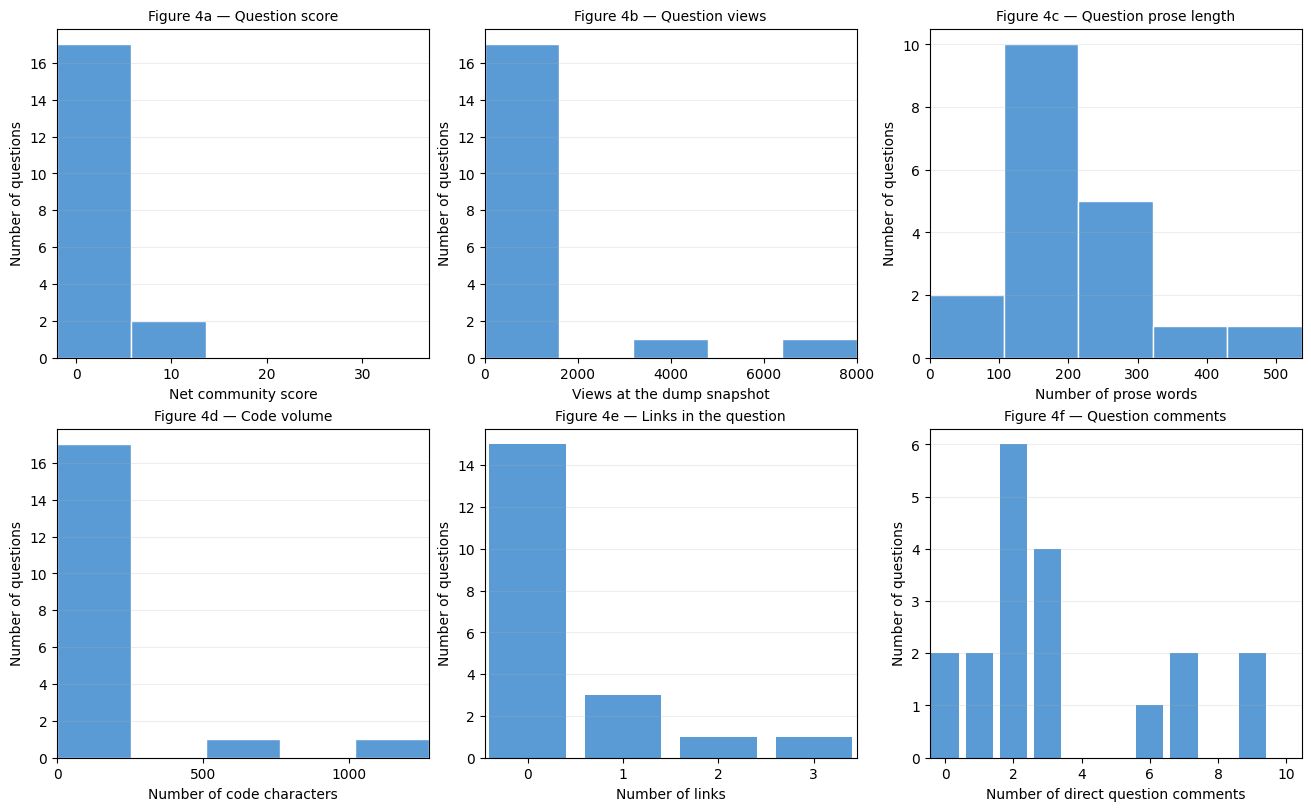

**Figure 4 interpretation**  
- **Figure 4a — Question score:** 20 values; median **1.0**; shown range **-2.0 to 37.0**; values below/above the range **0/1**; observed minimum/maximum **-2.0/42.0**.  
- **Figure 4b — Question views:** 20 values; median **592.5**; shown range **0.0 to 8,002.0**; values below/above the range **0/1**; observed minimum/maximum **150.0/12,103.0**.  
- **Figure 4c — Question prose length:** 20 values; median **190.5**; shown range **0.0 to 537.0**; values below/above the range **0/1**; observed minimum/maximum **68.0/568.0**.  
- **Figure 4d — Code volume:** 20 values; median **0.0**; shown range **0.0 to 1,273.0**; values below/above the range **0/1**; observed minimum/maximum **0.0/1,357.0**.  
- **Figure 4e — Links in the question:** 20 values; median **0.0**; shown range **0.0 to 3.0**; values below/above the range **0/0**; observed minimum/maximum **0.0/3.0**.  
- **Figure 4f — Question comments:** 20 values; median **2.5**; shown range **0.0 to 10.0**; values below/above the range **0/1**; observed minimum/maximum **0.0/11.0**.

In [16]:
# Figure 4: content and interaction measurements.
fig, axes = plt.subplots(2, 3, figsize=(13, 8), layout="constrained")
figure_4_results = []
for ax, (subfigure, title, x_label, column, whole, low_q, high_q) in zip(axes.flat, content_specs):
    result = draw_distribution(
        ax, data[column], f"Figure {subfigure} — {title}", x_label,
        whole_numbers=whole, lower_quantile=low_q, upper_quantile=high_q,
    )
    figure_4_results.append((subfigure, title, result))
plt.show()

lines = []
for subfigure, title, result in figure_4_results:
    if result is None:
        lines.append(f"- **Figure {subfigure} — {title}:** no value is available.")
        continue
    lines.append(
        f"- **Figure {subfigure} — {title}:** {result['available']:,} values; median **{result['median']:,.1f}**; "
        f"shown range **{result['lower']:,.1f} to {result['upper']:,.1f}**; "
        f"values below/above the range **{result['below']:,}/{result['above']:,}**; "
        f"observed minimum/maximum **{result['minimum']:,.1f}/{result['maximum']:,.1f}**."
    )
display(Markdown("**Figure 4 interpretation**  \n" + "  \n".join(lines)))
figure_status.append({"Figure": "4", "Status": "Produced", "Evidence": "Six content and interaction distributions"})

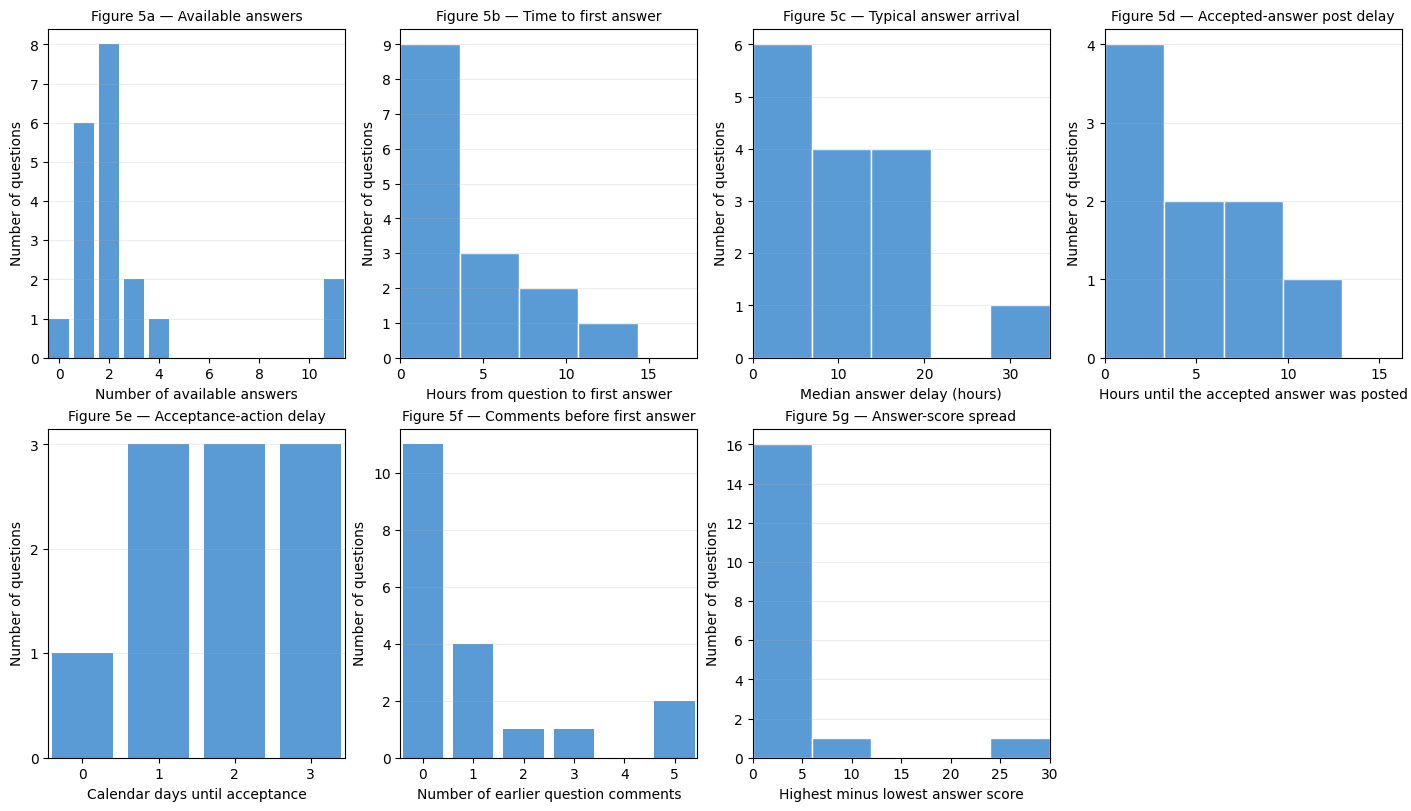

**Figure 5 interpretation**  
- **Figure 5a — Available answers:** 20 values; median **2.0**; shown range **0.0 to 11.0**; values below/above the range **0/0**; observed minimum/maximum **0.0/11.0**.  
- **Figure 5b — Time to first answer:** 19 values; median **5.1**; shown range **0.0 to 17.9**; values below/above the range **0/4**; observed minimum/maximum **0.1/395.6**.  
- **Figure 5c — Typical answer arrival:** 19 values; median **12.8**; shown range **0.0 to 34.6**; values below/above the range **0/4**; observed minimum/maximum **0.8/395.6**.  
- **Figure 5d — Accepted-answer post delay:** 12 values; median **6.1**; shown range **0.0 to 16.2**; values below/above the range **0/3**; observed minimum/maximum **0.3/95.9**.  
- **Figure 5e — Acceptance-action delay:** 12 values; median **2.0**; shown range **0.0 to 3.0**; values below/above the range **0/2**; observed minimum/maximum **0.0/12.0**.  
- **Figure 5f — Comments before first answer:** 19 values; median **0.0**; shown range **0.0 to 5.0**; values below/above the range **0/0**; observed minimum/maximum **0.0/5.0**.  
- **Figure 5g — Answer-score spread:** 19 values; median **1.0**; shown range **0.0 to 30.0**; values below/above the range **0/1**; observed minimum/maximum **0.0/44.0**.

In [17]:
# Figure 5: response and resolution measurements.
fig, axes = plt.subplots(2, 4, figsize=(14, 8), layout="constrained")
figure_5_results = []
for ax, (subfigure, title, x_label, column, whole, low_q, high_q) in zip(axes.flat, response_specs):
    result = draw_distribution(
        ax, data[column], f"Figure {subfigure} — {title}", x_label,
        whole_numbers=whole, lower_quantile=low_q, upper_quantile=high_q,
    )
    figure_5_results.append((subfigure, title, result))
axes.flat[-1].set_axis_off()
plt.show()

lines = []
for subfigure, title, result in figure_5_results:
    if result is None:
        lines.append(f"- **Figure {subfigure} — {title}:** no value is available because the corresponding event is absent.")
        continue
    lines.append(
        f"- **Figure {subfigure} — {title}:** {result['available']:,} values; median **{result['median']:,.1f}**; "
        f"shown range **{result['lower']:,.1f} to {result['upper']:,.1f}**; "
        f"values below/above the range **{result['below']:,}/{result['above']:,}**; "
        f"observed minimum/maximum **{result['minimum']:,.1f}/{result['maximum']:,.1f}**."
    )
display(Markdown("**Figure 5 interpretation**  \n" + "  \n".join(lines)))
figure_status.append({"Figure": "5", "Status": "Produced", "Evidence": "Seven response and resolution distributions"})

## 6. Figure 6 — Tukey high-outlier evidence

**Definition.** Tukey's rule identifies unusually high values using the third quartile plus 1.5 times the interquartile range. The interquartile range is the distance between the 25th and 75th percentiles.

**Interpretation.** The plot compares the percentage of questions above each field's threshold. The accompanying table gives the threshold and count. An outlier is an inspection candidate; its presence remains separate from data-error and difficulty classifications.

In [18]:
# Tukey thresholds and row-level flags.
outlier_labels = {
    "question_view_count": "Question views",
    "question_word_count": "Question prose words",
    "code_character_count": "Code characters",
    "available_answer_count": "Available answers",
    "available_question_comment_count": "Question comments",
    "time_to_first_answer_hours": "Hours to first answer",
    "time_to_eventually_accepted_answer_post_hours": "Hours to accepted-answer post",
    "answer_score_spread": "Answer-score spread",
}
outlier_flags = pd.DataFrame(False, index=data.index, columns=outlier_labels)
outlier_rows = []
for column, label in outlier_labels.items():
    values = data[column].dropna()
    if values.empty:
        q1 = q3 = threshold = np.nan
        count = 0
    else:
        q1, q3 = values.quantile([0.25, 0.75])
        threshold = q3 + 1.5 * (q3 - q1)
        outlier_flags[column] = data[column].gt(threshold).fillna(False)
        count = int(outlier_flags[column].sum())
    outlier_rows.append({
        "Measurement": label, "Available values": len(values),
        "25th percentile": q1, "75th percentile": q3,
        "High-outlier threshold": threshold, "High outliers": count,
        "Share of all questions (%)": 100 * count / len(data),
    })

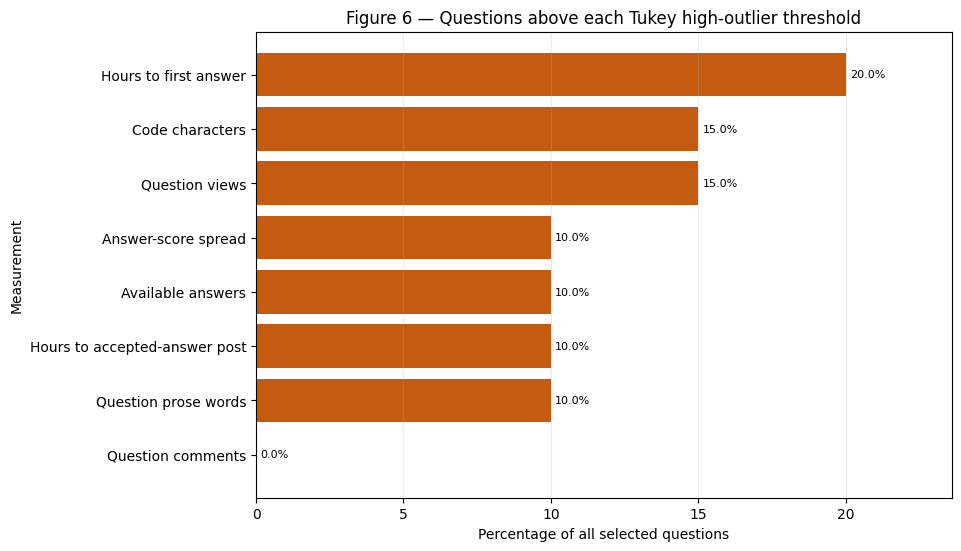

,Measurement,Available values,25th percentile,75th percentile,High-outlier threshold,High outliers,Share of all questions (%)
7,Answer-score spread,19,0.0,3.0,7.5,2,10.0
3,Available answers,20,1.0,2.2,4.1,2,10.0
2,Code characters,20,0.0,62.2,155.6,3,15.0
6,Hours to accepted-answer post,12,1.7,13.2,30.3,2,10.0
5,Hours to first answer,19,1.3,10.5,24.3,4,20.0
4,Question comments,20,2.0,6.2,12.6,0,0.0
1,Question prose words,20,153.0,268.2,441.1,2,10.0
0,Question views,20,316.5,957.8,1919.6,3,15.0


**Figure 6 interpretation**  
- **Hours to first answer** has the largest displayed high-outlier share: **4 questions (20.0%)**.  
- Thresholds are calculated separately for each measurement because their units and distributions differ.  
- The final inspection table links these statistical flags to concrete questions.

In [19]:
# Figure 6 and its threshold table.
outlier_summary = pd.DataFrame(outlier_rows).sort_values("Share of all questions (%)")
fig, ax = plt.subplots(figsize=(9.5, 5.4), layout="constrained")
bars = ax.barh(outlier_summary["Measurement"], outlier_summary["Share of all questions (%)"], color="#C55A11")
ax.set_title("Figure 6 — Questions above each Tukey high-outlier threshold")
ax.set_xlabel("Percentage of all selected questions")
ax.set_ylabel("Measurement")
ax.grid(axis="x", alpha=0.25)
ax.bar_label(bars, labels=[f"{value:.1f}%" for value in outlier_summary["Share of all questions (%)"]], padding=3, fontsize=8)
ax.set_xlim(0, max(1, outlier_summary["Share of all questions (%)"].max() * 1.18))
plt.show()

display(outlier_summary.sort_values("Measurement").round({
    "25th percentile": 1, "75th percentile": 1,
    "High-outlier threshold": 1, "Share of all questions (%)": 1,
}))
largest_outlier_group = outlier_summary.iloc[-1]
display(Markdown(
    "**Figure 6 interpretation**  \n"
    f"- **{largest_outlier_group['Measurement']}** has the largest displayed high-outlier share: "
    f"**{int(largest_outlier_group['High outliers']):,} questions ({largest_outlier_group['Share of all questions (%)']:.1f}%)**.  \n"
    "- Thresholds are calculated separately for each measurement because their units and distributions differ.  \n"
    "- The final inspection table links these statistical flags to concrete questions."
))
figure_status.append({"Figure": "6", "Status": "Produced", "Evidence": f"{len(outlier_summary)} Tukey thresholds"})

## 7. Figure 7 — Curated Spearman relationships

**Definition.** Spearman correlation measures whether two characteristics tend to rise or fall together after replacement of raw values with ranks.

**Interpretation.** Values approach `1` when both characteristics rise together, `−1` when one rises as the other falls, and `0` when ranked movement has little consistent pattern.

Each pair requires at least `MIN_CORRELATION_OBSERVATIONS` complete rows. Displayed pairs also satisfy the `MIN_ABSOLUTE_RHO` strength rule and the Benjamini–Hochberg `FDR_ALPHA` false-discovery-rate rule. Each heatmap row represents one retained pair, which removes the diagonal and unused matrix space. Correlation supports investigation; causal conclusions require a separate study.

In [20]:
# Exhaustive pair calculation for a curated set of interpretable measurements.
correlation_labels = {
    "question_word_count": "Prose words",
    "code_character_count": "Code characters",
    "link_count": "Links",
    "image_count": "Images",
    "tag_count": "Tags",
    "question_score": "Question score",
    "question_view_count": "Views",
    "available_answer_count": "Available answers",
    "available_question_comment_count": "Question comments",
    "comments_before_first_answer": "Comments before first answer",
    "time_to_first_answer_hours": "Hours to first answer",
    "median_answer_response_hours": "Median answer delay",
    "time_to_eventually_accepted_answer_post_hours": "Hours to accepted-answer post",
    "days_to_acceptance": "Days to acceptance",
    "answer_score_spread": "Answer-score spread",
    "observation_days_at_dump": "Observation days",
}
structural_pairs = {frozenset(("link_count", "image_count"))}
pair_results = []
for first, second in combinations(correlation_labels, 2):
    if frozenset((first, second)) in structural_pairs:
        continue
    pair = data[[first, second]].dropna()
    if len(pair) < MIN_CORRELATION_OBSERVATIONS:
        continue
    if pair[first].nunique() < 2 or pair[second].nunique() < 2:
        continue
    rho, p_value = stats.spearmanr(pair[first], pair[second])
    pair_results.append({
        "first": first, "second": second, "rho": rho,
        "p_value": p_value, "observations": len(pair),
    })

correlations = pd.DataFrame(pair_results)
if correlations.empty:
    meaningful = correlations.copy()
else:
    correlations["q_value"] = stats.false_discovery_control(
        correlations["p_value"].to_numpy(), method="bh"
    )
    meaningful = correlations[
        (correlations["rho"].abs() >= MIN_ABSOLUTE_RHO)
        & (correlations["q_value"] <= FDR_ALPHA)
    ].copy()

In [21]:
if meaningful.empty:
    display(Markdown(
        "**Figure 7 is unavailable.** No pair satisfies the sample-size, strength, "
        "and false-discovery-rate rules in this table."
    ))
    figure_status.append({"Figure": "7", "Status": "Unavailable", "Evidence": "No pair passed all rules"})
else:
    meaningful["pair_label"] = [
        f"{correlation_labels[first]}  ↔  {correlation_labels[second]}"
        for first, second in zip(meaningful["first"], meaningful["second"])
    ]
    meaningful = meaningful.reindex(meaningful["rho"].abs().sort_values(ascending=False).index)
    figure_height = min(10, max(3.2, 1.4 + 0.38 * len(meaningful)))
    fig, ax = plt.subplots(figsize=(7.8, figure_height), layout="constrained")
    image = ax.imshow(meaningful[["rho"]].to_numpy(), aspect="auto", vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_yticks(range(len(meaningful)), meaningful["pair_label"])
    ax.set_xticks([0], ["Spearman correlation (rho)"])
    ax.set_title("Figure 7 — Meaningful Spearman relationships")
    for row_number, rho in enumerate(meaningful["rho"]):
        ax.text(0, row_number, f"{rho:.2f}", ha="center", va="center")
    color_bar = fig.colorbar(image, ax=ax, shrink=0.82)
    color_bar.set_label("Relationship direction and strength")
    plt.show()

    lines = []
    for row in meaningful.head(4).itertuples():
        direction = "rise together" if row.rho > 0 else "move in opposite directions"
        q_text = "< 1e-300" if row.q_value == 0 else f"{row.q_value:.3g}"
        lines.append(
            f"- **{correlation_labels[row.first]}** and **{correlation_labels[row.second]}** "
            f"{direction} (rho = {row.rho:.2f}; q-value {q_text}; complete questions = {row.observations:,})."
        )
    display(Markdown(
        "**Figure 7 interpretation**  \n" + "  \n".join(lines)
        + "  \n- These relationships identify hypotheses and cases for closer analysis."
    ))
    figure_status.append({"Figure": "7", "Status": "Produced", "Evidence": f"{len(meaningful)} retained pairs"})

**Figure 7 is unavailable.** No pair satisfies the sample-size, strength, and false-discovery-rate rules in this table.

## 8. Figure 8 — Tags and response outcomes

A tag names a question topic. One question can carry several tags, so tag totals overlap. Figure 8a reports frequent topics. Figure 8b compares answer and acceptance percentages for tags supported by at least `MIN_TAG_QUESTIONS` questions.

In [22]:
# Tag frequencies and outcome summaries.
tag_rows = data[["question_id", "question_tags"]].dropna(subset=["question_tags"]).copy()
tag_rows["tag"] = tag_rows["question_tags"].str.split(";")
tag_rows = tag_rows.explode("tag")
tag_rows["tag"] = tag_rows["tag"].str.strip()
tag_rows = tag_rows[tag_rows["tag"] != ""]
tag_frequency = tag_rows["tag"].value_counts()
top_tags = tag_frequency.head(TOP_TAGS_TO_SHOW).sort_values()

tag_outcomes = tag_rows.merge(
    data[["question_id", "has_available_answer", "has_accepted_answer"]],
    on="question_id", how="left",
)
tag_summary = tag_outcomes.groupby("tag").agg(
    questions=("question_id", "nunique"),
    answered_percentage=("has_available_answer", "mean"),
    accepted_percentage=("has_accepted_answer", "mean"),
)
tag_summary[["answered_percentage", "accepted_percentage"]] *= 100
eligible_tags = tag_summary[tag_summary["questions"] >= MIN_TAG_QUESTIONS]
eligible_tags = eligible_tags.sort_values("questions", ascending=False).head(TOP_TAGS_TO_SHOW)
eligible_tags = eligible_tags.sort_values("answered_percentage")

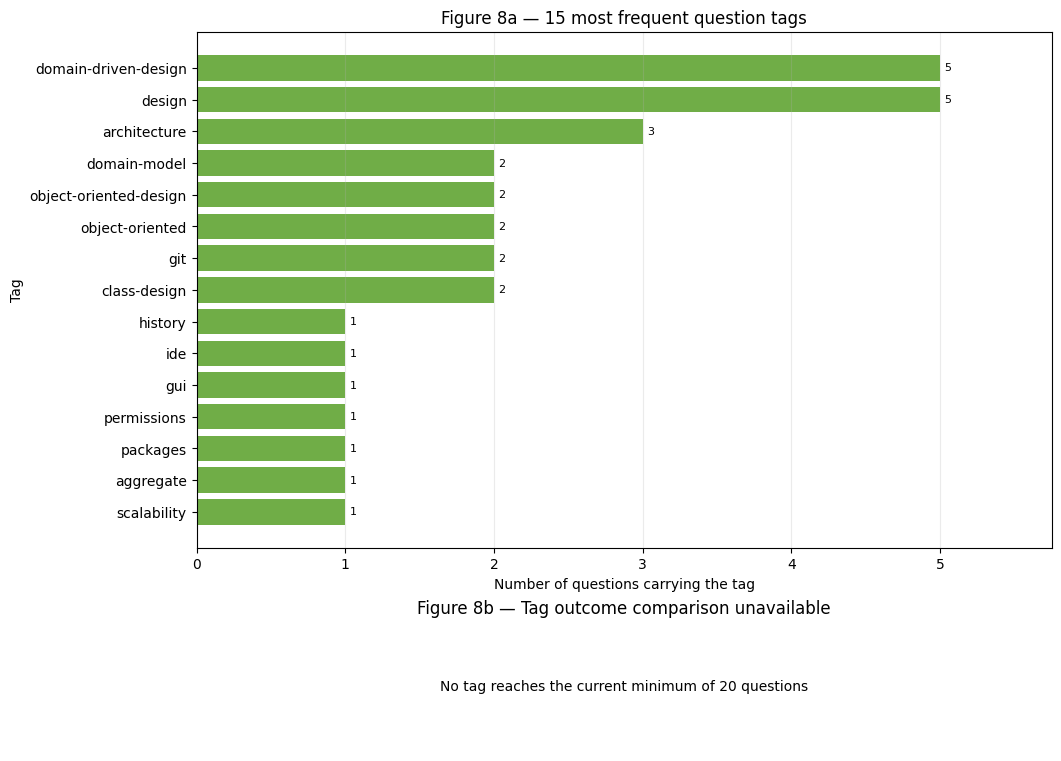

In [23]:
# Figure 8 frequency and outcome panels.
if eligible_tags.empty:
    figure_height = min(8.0, max(6.5, 4.2 + 0.22 * len(top_tags)))
    height_ratios = [4, 1]
else:
    figure_height = min(10.5, max(8.0, 4.0 + 0.22 * (len(top_tags) + len(eligible_tags))))
    height_ratios = [max(4, len(top_tags)), max(4, len(eligible_tags))]
fig, axes = plt.subplots(
    2, 1, figsize=(10.5, figure_height),
    gridspec_kw={"height_ratios": height_ratios}, layout="constrained",
)
if top_tags.empty:
    axes[0].text(0.5, 0.5, "No question tags are available", ha="center", va="center")
    axes[0].set_axis_off()
else:
    bars = axes[0].barh(top_tags.index, top_tags.values, color="#70AD47")
    axes[0].set_title(f"Figure 8a — {len(top_tags)} most frequent question tags")
    axes[0].set_xlabel("Number of questions carrying the tag")
    axes[0].set_ylabel("Tag")
    axes[0].grid(axis="x", alpha=0.25)
    axes[0].bar_label(bars, labels=[f"{value:,}" for value in top_tags.values], padding=3, fontsize=8)
    axes[0].set_xlim(0, max(1, top_tags.max() * 1.15))

if eligible_tags.empty:
    axes[1].text(
        0.5, 0.5,
        f"No tag reaches the current minimum of {MIN_TAG_QUESTIONS} questions",
        ha="center", va="center", transform=axes[1].transAxes,
    )
    axes[1].set_title("Figure 8b — Tag outcome comparison unavailable")
    axes[1].set_axis_off()
else:
    positions = np.arange(len(eligible_tags))
    axes[1].barh(positions - 0.18, eligible_tags["answered_percentage"], height=0.36, label="At least one answer")
    axes[1].barh(positions + 0.18, eligible_tags["accepted_percentage"], height=0.36, label="Accepted answer")
    tag_axis_labels = [f"{tag} (n={int(eligible_tags.loc[tag, 'questions'])})" for tag in eligible_tags.index]
    axes[1].set_yticks(positions, tag_axis_labels)
    axes[1].set_xlim(0, 100)
    axes[1].set_title(f"Figure 8b — Outcomes for tags with at least {MIN_TAG_QUESTIONS} questions")
    axes[1].set_xlabel("Percentage of questions carrying the tag")
    axes[1].set_ylabel("Tag")
    axes[1].grid(axis="x", alpha=0.25)
    axes[1].legend(frameon=False, loc="best")
plt.show()

In [24]:
# Figure 8 interpretation and availability status.
if top_tags.empty:
    display(Markdown("**Figure 8 interpretation.** The selected table contains no available tags."))
    figure_status.append({"Figure": "8", "Status": "Unavailable", "Evidence": "No tags"})
elif eligible_tags.empty:
    display(Markdown(
        f"**Figure 8 interpretation.** **{tag_frequency.index[0]}** is the most frequent tag "
        f"({tag_frequency.iloc[0]:,} questions). Topic frequency is available; the outcome comparison "
        f"requires at least {MIN_TAG_QUESTIONS} questions per tag."
    ))
    figure_status.append({"Figure": "8", "Status": "Partial", "Evidence": "Tag frequencies available; no eligible outcome groups"})
else:
    highest = eligible_tags["answered_percentage"].idxmax()
    lowest = eligible_tags["answered_percentage"].idxmin()
    display(Markdown(
        f"**Figure 8 interpretation.** **{tag_frequency.index[0]}** is the most frequent tag "
        f"({tag_frequency.iloc[0]:,} questions). Among eligible tags, **{highest}** has the highest answered share "
        f"({eligible_tags.loc[highest, 'answered_percentage']:.1f}%) and **{lowest}** has the lowest "
        f"({eligible_tags.loc[lowest, 'answered_percentage']:.1f}%)."
    ))
    figure_status.append({"Figure": "8", "Status": "Produced", "Evidence": f"{len(top_tags)} frequent and {len(eligible_tags)} eligible tags"})

**Figure 8 interpretation.** **design** is the most frequent tag (5 questions). Topic frequency is available; the outcome comparison requires at least 20 questions per tag.

## 9. Questions selected for inspection

The table links Tukey flags to concrete questions. Rows with several high-outlier measurements receive priority, followed by long first-answer delays and high question-comment counts. These entries support qualitative inspection. Difficulty labels require a documented manual assessment.

In [25]:
data["high_outlier_field_count"] = outlier_flags.sum(axis=1)

def outlier_reason(row_index):
    """Returns up to three high-outlier measurement labels for one question."""
    labels = [outlier_labels[column] for column in outlier_labels if outlier_flags.loc[row_index, column]]
    return "; ".join(labels[:3]) if labels else "High available inspection values"

data["selection_reason"] = [outlier_reason(index) for index in data.index]
cases = data.sort_values(
    ["high_outlier_field_count", "time_to_first_answer_hours", "available_question_comment_count"],
    ascending=[False, False, False], na_position="last",
).head(MAX_CASES_TO_SHOW).copy()
cases["question_title"] = cases["question_title"].fillna("").str.slice(0, 90)
cases_to_show = cases[[
    "selection_reason", "high_outlier_field_count", "question_id", "question_title",
    "question_url", "available_answer_count", "available_question_comment_count",
    "time_to_first_answer_hours",
]].rename(columns={
    "selection_reason": "High-outlier measurements",
    "high_outlier_field_count": "Tukey flags",
    "question_id": "Question ID",
    "question_title": "Question title (first 90 characters)",
    "question_url": "Question URL",
    "available_answer_count": "Available answers",
    "available_question_comment_count": "Question comments",
    "time_to_first_answer_hours": "Hours to first answer",
})
display(cases_to_show)

,High-outlier measurements,Tukey flags,Question ID,Question title (first 90 characters),Question URL,Available answers,Question comments,Hours to first answer
8,Question views; Available answers; Answer-scor...,3,450386,Where to keep the code that I do not want in t...,https://softwareengineering.stackexchange.com/...,11,7,0.251918
7,Question views; Available answers; Answer-scor...,3,450379,What do you do with branches you've abandoned?,https://softwareengineering.stackexchange.com/...,11,2,0.143861
2,Hours to first answer; Hours to accepted-answe...,2,450359,Offering multiple versions of artifact heavy p...,https://softwareengineering.stackexchange.com/...,2,1,35.570644
1,Hours to first answer,1,450356,How to make a hierarchical permission architec...,https://softwareengineering.stackexchange.com/...,1,3,395.622293
12,Hours to first answer,1,450414,Orchestrator (like Camunda) between frontend a...,https://softwareengineering.stackexchange.com/...,2,3,30.985681
4,Hours to first answer,1,450361,Splitting up large SQLAlchemy model,https://softwareengineering.stackexchange.com/...,2,1,27.169258
6,Code characters,1,450374,Should domain services in a domain-driven desi...,https://softwareengineering.stackexchange.com/...,1,2,9.218981
0,Hours to accepted-answer post,1,450355,What was the first company to make a drag-and-...,https://softwareengineering.stackexchange.com/...,3,9,7.690655


## 10. Run status and result applications

- Figures 1–3 describe table quality, overall outcomes, cumulative evolution, and posting cohorts.
- Figures 4–6 describe content, response, resolution, and high-outlier patterns.
- Figure 7 reports statistically supported associations when sufficient evidence is available.
- Figure 8 supports topic-group comparison.
- Section 9 provides concrete questions for qualitative inspection.
- Human and model difficulty require separate documented evaluation protocols.

In [26]:
# Final evidence that every preceding cell completed.
status_table = pd.DataFrame(figure_status)
display(status_table)

produced = int((status_table["Status"] == "Produced").sum())
partial = int((status_table["Status"] == "Partial").sum())
unavailable = int((status_table["Status"] == "Unavailable").sum())
display(Markdown(
    "**Run complete.**  \n"
    f"- Input file: `{DATA_FILE}`  \n"
    f"- Loaded table: **{len(data):,} rows × {source_column_count:,} source columns**  \n"
    f"- Figure groups produced: **{produced}**  \n"
    f"- Figure groups partially available: **{partial}**  \n"
    f"- Figure groups unavailable because evidence was insufficient: **{unavailable}**  \n"
    "- Execution reached the final cell without a notebook exception."
))

,Figure,Status,Evidence
0,1,Produced,"Outcome, availability, and consistency checks"
1,2,Produced,28 cumulative calendar months
2,3,Produced,1 creation-month cohorts
3,4,Produced,Six content and interaction distributions
4,5,Produced,Seven response and resolution distributions
5,6,Produced,8 Tukey thresholds
6,7,Unavailable,No pair passed all rules
7,8,Partial,Tag frequencies available; no eligible outcome...


**Run complete.**  
- Input file: `../data/examples/characteristics_pilot.tsv`  
- Loaded table: **20 rows × 49 source columns**  
- Figure groups produced: **6**  
- Figure groups partially available: **1**  
- Figure groups unavailable because evidence was insufficient: **1**  
- Execution reached the final cell without a notebook exception.